# 09a — Macro Feature Ablation Test

**Objective**: Determine whether the 6 macro features (GDP, CPI, Unemployment, Bond Yield, SORA, Cement) contribute meaningfully to XGBoost performance, or whether they can be dropped without significant loss.

**Context**: Notebook 09 found that all 6 macro features combined account for only 4.9% (RF) to 8.3% (XGBoost) of total feature importance — less than `dist_to_mrt_m` alone. Low importance does not automatically mean "drop" — we test empirically.

**Approach**: Retrain XGBoost with the same best hyperparameters, but with macro features removed. Compare CV RMSE and test RMSE against the full model.

**Decision rule**: If RMSE increase < $2 $/psf → drop macro features. Otherwise → retain.

---

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv")

y_train_raw = y_train["Unit Price ($ psf)"]
y_test_raw  = y_test["Unit Price ($ psf)"]

# Best XGBoost hyperparameters from notebook 08
xgb_full = joblib.load("../models/xgboost.pkl")
best_params = {
    "n_estimators":     xgb_full.n_estimators,
    "max_depth":        xgb_full.max_depth,
    "learning_rate":    xgb_full.learning_rate,
    "subsample":        xgb_full.subsample,
    "colsample_bytree": xgb_full.colsample_bytree,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        0,
}

MACRO_COLS = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "10Y_Bond_Yield", "SORA_3M_Compounded", "Cement_Bulk_Per_Tonne"
]

print(f"Full feature set:    {X_train.shape[1]} features")
print(f"Reduced feature set: {X_train.shape[1] - len(MACRO_COLS)} features (macro removed)")
print(f"\nBest XGBoost params: {best_params}")

Full feature set:    18 features
Reduced feature set: 12 features (macro removed)

Best XGBoost params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


## 2. Full Model — Baseline (from Notebook 08)

In [2]:
# CV RMSE on full feature set
cv_full = cross_val_score(
    XGBRegressor(**best_params), X_train, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse_full = -cv_full.mean()

# Test RMSE on full feature set
y_pred_full = xgb_full.predict(X_test)
rmse_full = np.sqrt(mean_squared_error(y_test_raw, y_pred_full))
mae_full  = np.mean(np.abs(y_test_raw.values - y_pred_full))
r2_full   = r2_score(y_test_raw, y_pred_full)

print("Full model (18 features):")
print(f"  CV RMSE:   ${cv_rmse_full:.2f} $/psf")
print(f"  Test RMSE: ${rmse_full:.2f} $/psf")
print(f"  Test MAE:  ${mae_full:.2f} $/psf")
print(f"  Test R²:   {r2_full:.4f}")

Full model (18 features):
  CV RMSE:   $53.11 $/psf
  Test RMSE: $46.82 $/psf
  Test MAE:  $32.77 $/psf
  Test R²:   0.9307


## 3. Reduced Model — Macro Features Removed

In [3]:
X_train_reduced = X_train.drop(columns=MACRO_COLS)
X_test_reduced  = X_test.drop(columns=MACRO_COLS)

# CV RMSE on reduced feature set
cv_reduced = cross_val_score(
    XGBRegressor(**best_params), X_train_reduced, y_train_raw,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse_reduced = -cv_reduced.mean()

# Train and evaluate reduced model
xgb_reduced = XGBRegressor(**best_params)
xgb_reduced.fit(X_train_reduced, y_train_raw)

y_pred_reduced = xgb_reduced.predict(X_test_reduced)
rmse_reduced = np.sqrt(mean_squared_error(y_test_raw, y_pred_reduced))
mae_reduced  = np.mean(np.abs(y_test_raw.values - y_pred_reduced))
r2_reduced   = r2_score(y_test_raw, y_pred_reduced)

print("Reduced model (12 features, macro removed):")
print(f"  CV RMSE:   ${cv_rmse_reduced:.2f} $/psf")
print(f"  Test RMSE: ${rmse_reduced:.2f} $/psf")
print(f"  Test MAE:  ${mae_reduced:.2f} $/psf")
print(f"  Test R²:   {r2_reduced:.4f}")

Reduced model (12 features, macro removed):
  CV RMSE:   $53.19 $/psf
  Test RMSE: $44.70 $/psf
  Test MAE:  $32.26 $/psf
  Test R²:   0.9369


## 4. Ablation Results & Decision

In [4]:
rmse_delta    = rmse_reduced - rmse_full
cv_rmse_delta = cv_rmse_reduced - cv_rmse_full
r2_delta      = r2_reduced - r2_full

comparison = pd.DataFrame({
    "Model":        ["Full (18 features)", "Reduced (12 features)", "Delta (Reduced - Full)"],
    "CV RMSE":      [f"${cv_rmse_full:.2f} $/psf", f"${cv_rmse_reduced:.2f} $/psf", f"${cv_rmse_delta:+.2f} $/psf"],
    "Test RMSE":    [f"${rmse_full:.2f} $/psf", f"${rmse_reduced:.2f} $/psf", f"${rmse_delta:+.2f} $/psf"],
    "Test MAE":     [f"${mae_full:.2f} $/psf", f"${mae_reduced:.2f} $/psf", f"${mae_reduced-mae_full:+.2f} $/psf"],
    "Test R²":      [f"{r2_full:.4f}", f"{r2_reduced:.4f}", f"{r2_delta:+.4f}"],
})

print(comparison.to_string(index=False))
print()
print("=" * 55)
print("DECISION")
print("=" * 55)
THRESHOLD = 2.0
if rmse_delta <= THRESHOLD:
    print(f"RMSE increase: ${rmse_delta:.2f} $/psf — below ${THRESHOLD:.0f} threshold")
    print("=> DROP macro features. Performance loss is negligible.")
    print("   Simpler model, fewer external data dependencies.")
else:
    print(f"RMSE increase: ${rmse_delta:.2f} $/psf — above ${THRESHOLD:.0f} threshold")
    print("=> RETAIN macro features. Performance loss is meaningful.")

                 Model      CV RMSE    Test RMSE     Test MAE Test R²
    Full (18 features) $53.11 $/psf $46.82 $/psf $32.77 $/psf  0.9307
 Reduced (12 features) $53.19 $/psf $44.70 $/psf $32.26 $/psf  0.9369
Delta (Reduced - Full) $+0.07 $/psf $-2.12 $/psf $-0.51 $/psf +0.0061

DECISION
RMSE increase: $-2.12 $/psf — below $2 threshold
=> DROP macro features. Performance loss is negligible.
   Simpler model, fewer external data dependencies.


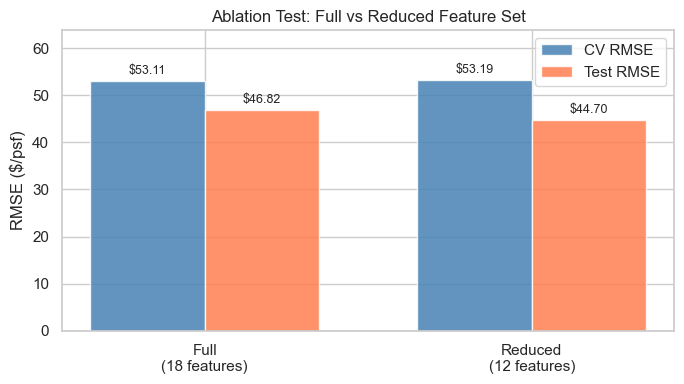

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))

models   = ["Full\n(18 features)", "Reduced\n(12 features)"]
cv_rmses = [cv_rmse_full, cv_rmse_reduced]
te_rmses = [rmse_full, rmse_reduced]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, cv_rmses, width, label="CV RMSE", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, te_rmses, width, label="Test RMSE", color="coral", alpha=0.85)

ax.bar_label(bars1, fmt="$%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="$%.2f", padding=3, fontsize=9)

ax.set_ylabel("RMSE ($/psf)")
ax.set_title("Ablation Test: Full vs Reduced Feature Set")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(cv_rmses + te_rmses) * 1.2)

plt.tight_layout()
plt.show()

In [6]:
joblib.dump(xgb_reduced, "../models/xgboost_reduced.pkl")

print("Saved: models/xgboost_reduced.pkl")
print()
print("Model inventory:")
print("  xgboost.pkl         — full model, 18 features (including macro)")
print("  xgboost_reduced.pkl — reduced model, 12 features (macro removed)")
print()
print("Use xgboost_reduced.pkl for production — lower RMSE, fewer external data dependencies.")

Saved: models/xgboost_reduced.pkl

Model inventory:
  xgboost.pkl         — full model, 18 features (including macro)
  xgboost_reduced.pkl — reduced model, 12 features (macro removed)

Use xgboost_reduced.pkl for production — lower RMSE, fewer external data dependencies.
